In [53]:
import pandas as pd
import seaborn as sb
data = pd.read_csv('student-mat.csv')
data.head(10)


,school,gender,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,3,4,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,3,10,7,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,5,2,15,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,5,4,6,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,yes,yes,no,5,4,2,5,10,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,yes,yes,no,4,4,4,3,0,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,yes,no,no,4,1,4,1,6,6,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,yes,yes,no,4,2,2,1,0,16,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,yes,yes,no,5,5,1,5,0,14,15


Потенциально влияющие факторы и анализ информации:
school — школа, в которой учится ученик(школа может влиять на оценку ученика)
age -  возраст ученика 
address - тип местности может влиять (город или пригород)
famsize - кол-во людей в семье (влияет братья сестра могут помогать в учебе)
Medu - Fedu (гипотеза: совпадают образования родителей)
Mjob - Fjob (гипотеза: работа матери и работа отца коррелируют)
!важные факторы!
reason - причина учебы
traveltime - время до школы
studytime - время на учебу в неделю
failures - незачетыпо предмету в прошлом
schoolsup 
famsup
paid - доп занаятия по предмету
activities - внеуч деятельонсть 
nursery - подготовительная школа?
higher - хочет во или нет
internet - интернет дома
romantic
famrel -семейные отношения
freetime - свободное время после школы
goout - время с друзьями
health - проблемы со здоровьем
absences - пропуски
G1 - оценка за первый период


In [54]:
from sklearn.model_selection import train_test_split
X = data.drop('G3',axis = 1,inplace = False)
y = data['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 50)
print(len(X_test))
print(len(X_train))
y.head(10)


50
345


0     6
1     6
2    10
3    15
4    10
5    15
6    11
7     6
8    19
9    15
Name: G3, dtype: int64

<Axes: xlabel='G3', ylabel='Count'>

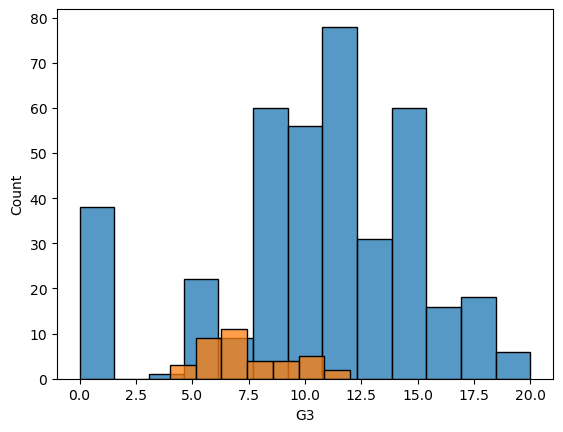

In [55]:
sb.histplot(data['G3'])
sb.histplot(data[data['G3']==0]['G1'])

<Axes: xlabel='G3', ylabel='Count'>

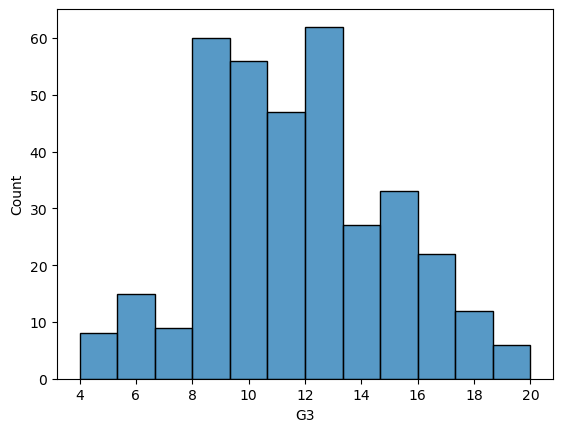

In [56]:
data = data[data['G3']!= 0]
sb.histplot(data['G3'])

In [ ]:
X_y_train = X_train.copy(deep = True)
X_y_train['y'] = y_train
corr = X_y_train.corr(numeric_only=True)['y']
corr = corr[abs(corr)>=0.1]
corr

age          -0.179792
Medu          0.214521
Fedu          0.137744
traveltime   -0.123325
failures     -0.350345
goout        -0.152477
G1            0.800268
y             1.000000
Name: y, dtype: float64

<Axes: xlabel='G1', ylabel='y'>

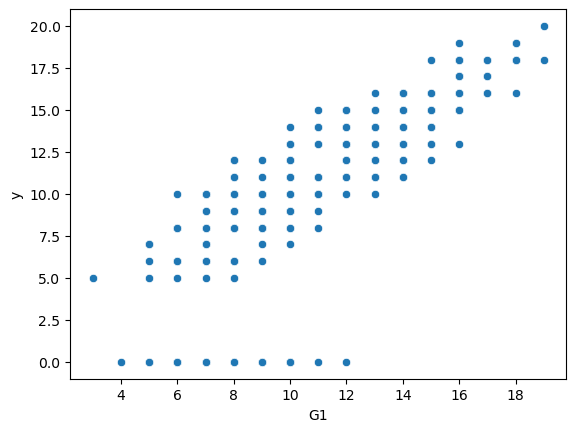

In [58]:
sb.scatterplot(x=X_y_train['G1'],y=X_y_train['y'])

<Axes: xlabel='school', ylabel='y'>

c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


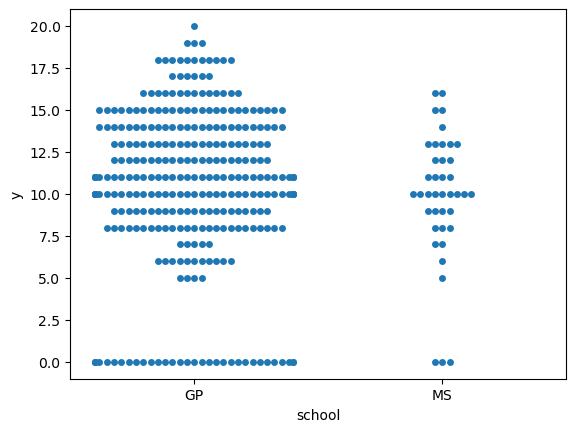

In [59]:
sb.swarmplot(x=X_y_train['school'],y=X_y_train['y'])

In [60]:
numeric_factors_to_use = ['age', 'traveltime', 'G1', 'studytime', 'Medu','failures','absences']

In [61]:
X_y_train.groupby('higher', as_index = False).agg({'y':'mean'})

,higher,y
0,no,6.823529
1,yes,10.637195


In [62]:
interesting_categorical_factors = ['Mjob', 'Fjob', 'schoolsup', 'higher','reason']

In [63]:
from category_encoders.target_encoder import TargetEncoder


In [64]:
!pip3 install category_encoders

In [65]:
mjob_target_encoder = TargetEncoder()
mjob_target_encoder.fit(X_y_train['Mjob'],X_y_train['y'])

fjob_target_encoder = TargetEncoder()
fjob_target_encoder.fit(X_y_train['Fjob'], X_y_train['y'])

schoolsup_target_encoder = TargetEncoder()
schoolsup_target_encoder.fit(X_y_train['schoolsup'], X_y_train['y'])

higher_target_encoder = TargetEncoder()
higher_target_encoder.fit(X_y_train['higher'], X_y_train['y'])

,verbose,0
,cols,['higher']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None


In [66]:
X_y_train['Mjob_encoded'] = mjob_target_encoder.transform(X_y_train['Mjob'])
X_y_train['Fjob_encoded'] = fjob_target_encoder.transform(X_y_train['Fjob'])
X_y_train['schoolsup_encoded'] = schoolsup_target_encoder.transform(X_y_train['schoolsup'])
X_y_train['higher_encoded'] = higher_target_encoder.transform(X_y_train['higher'])
X_y_train

,school,gender,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,health,absences,G1,y,Mjob_encoded,Fjob_encoded,schoolsup_encoded,higher_encoded
265,GP,M,18,R,LE3,A,3,4,other,other,...,2,5,1,13,17,17,9.856016,10.138298,10.61,10.637195
170,GP,M,16,U,GT3,T,3,4,other,other,...,4,5,2,0,6,0,9.856016,10.138298,10.61,10.637195
93,GP,F,16,U,GT3,T,4,2,teacher,services,...,3,3,1,0,11,10,11.042868,10.373765,10.61,10.637195
298,GP,F,18,U,GT3,T,4,3,other,other,...,3,3,3,0,14,14,9.856016,10.138298,10.61,10.637195
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,5,2,15,15,11.665062,10.373765,10.61,10.637195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,GP,F,16,U,GT3,A,3,4,services,other,...,2,1,5,16,12,11,11.064758,10.138298,10.61,10.637195
186,GP,M,16,U,GT3,T,1,2,services,services,...,3,3,3,2,11,11,11.064758,10.373765,10.61,10.637195
37,GP,M,16,R,GT3,A,4,4,other,teacher,...,4,3,5,7,15,15,9.856016,11.577238,10.61,10.637195
302,GP,F,17,U,GT3,T,4,2,other,other,...,3,3,3,0,15,14,9.856016,10.138298,10.61,10.637195


In [67]:
factors_to_use = numeric_factors_to_use + ['Mjob_encoded', 'Fjob_encoded', 'schoolsup_encoded', 'higher_encoded']
X_train_encoded = X_y_train.copy(deep=True)
X_train_encoded = X_train_encoded[factors_to_use]
X_train_encoded

,age,traveltime,G1,studytime,Medu,failures,absences,Mjob_encoded,Fjob_encoded,schoolsup_encoded,higher_encoded
265,18,2,17,2,3,0,13,9.856016,10.138298,10.61,10.637195
170,16,3,6,1,3,2,0,9.856016,10.138298,10.61,10.637195
93,16,2,11,2,4,0,0,11.042868,10.373765,10.61,10.637195
298,18,1,14,4,4,0,0,9.856016,10.138298,10.61,10.637195
3,15,1,15,3,4,0,2,11.665062,10.373765,10.61,10.637195
...,...,...,...,...,...,...,...,...,...,...,...
133,16,1,12,1,3,0,16,11.064758,10.138298,10.61,10.637195
186,16,1,11,1,1,0,2,11.064758,10.373765,10.61,10.637195
37,16,2,15,3,4,0,7,9.856016,11.577238,10.61,10.637195
302,17,2,15,3,4,0,0,9.856016,10.138298,10.61,10.637195


In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train_encoded)
X_train_scaled = scaler.transform(X_train_encoded)
X_train_scaled

array([[0.5       , 0.33333333, 0.875     , ..., 0.        , 1.        ,
        1.        ],
       [0.16666667, 0.66666667, 0.1875    , ..., 0.        , 1.        ,
        1.        ],
       [0.16666667, 0.33333333, 0.5       , ..., 0.16363957, 1.        ,
        1.        ],
       ...,
       [0.16666667, 0.33333333, 0.75      , ..., 1.        , 1.        ,
        1.        ],
       [0.33333333, 0.33333333, 0.75      , ..., 0.        , 1.        ,
        1.        ],
       [0.33333333, 0.33333333, 0.5625    , ..., 0.        , 1.        ,
        1.        ]], shape=(345, 11))

In [82]:
import numpy as np
print(X_train_scaled[:6])
X_train_encoded.head(6)

[[0.5        0.33333333 0.875      0.33333333 0.75       0.
  0.17333333 0.24805257 0.         1.         1.        ]
 [0.16666667 0.66666667 0.1875     0.         0.75       0.66666667
  0.         0.24805257 0.         1.         1.        ]
 [0.16666667 0.33333333 0.5        0.33333333 1.         0.
  0.         0.74137909 0.16363957 1.         1.        ]
 [0.5        0.         0.6875     1.         1.         0.
  0.         0.24805257 0.         1.         1.        ]
 [0.         0.         0.75       0.66666667 1.         0.
  0.02666667 1.         0.16363957 1.         1.        ]
 [0.33333333 0.         0.4375     0.66666667 0.75       0.
  0.05333333 0.24805257 0.         1.         1.        ]]


,age,traveltime,G1,studytime,Medu,failures,absences,Mjob_encoded,Fjob_encoded,schoolsup_encoded,higher_encoded
265,18,2,17,2,3,0,13,9.856016,10.138298,10.61,10.637195
170,16,3,6,1,3,2,0,9.856016,10.138298,10.61,10.637195
93,16,2,11,2,4,0,0,11.042868,10.373765,10.61,10.637195
298,18,1,14,4,4,0,0,9.856016,10.138298,10.61,10.637195
3,15,1,15,3,4,0,2,11.665062,10.373765,10.61,10.637195
263,17,1,10,3,3,0,4,9.856016,10.138298,10.61,10.637195


In [83]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
model.score(X_train_scaled, y_train)

0.6721342285657352

In [85]:
X_test['Mjob_encoded'] = mjob_target_encoder.transform(X_test['Mjob'])
X_test['Fjob_encoded'] = fjob_target_encoder.transform(X_test['Fjob'])
X_test['schoolsup_encoded'] = schoolsup_target_encoder.transform(X_test['schoolsup'])
X_test['higher_encoded'] = higher_target_encoder.transform(X_test['higher'])

In [86]:
X_test_encoded = X_test[factors_to_use]

In [ ]:
X_test_sacled=scaler.transform(X_test_encoded)


In [88]:
model.score(X_test_sacled,y_test)

0.6704576072113122

In [89]:
def score_model(model, X_test, y_test):
    y_preds = model.predict(X_test)
    
    errs = []
    
    for y, y_pred in zip(y_test, y_preds):
        errs.append(abs(y - y_pred))
        
    mae = sum(errs) / len(errs)
    
    mean_y_test = sum(y_test) / len(y_test)
    r2 = 1 - sum(err ** 2 for err in errs) / sum((y - mean_y_test) ** 2 for y in y_test)
    
    return mae, r2

In [90]:
score_model(model,X_test_sacled,y_test)

(np.float64(1.8537975836321885), np.float64(0.6704576072113124))

In [91]:
maes = []
r2s = []

X_y_test = X_test_encoded.copy(deep=True)
X_y_test['y'] = y_test

for i in range(1000):
    X_y_sample = X_y_test.sample(len(X_y_test), replace=True)
    
    X_test_sample = X_y_sample.drop(columns=['y'])
    X_test_sample = scaler.transform(X_test_sample)
    y_test_sample = X_y_sample['y']
    
    mae_sample, r2_sample = score_model(model, X_test_sample, y_test_sample)
    
    maes.append(mae_sample)
    r2s.append(r2_sample)

In [93]:
maes = list(sorted(maes))
maes

[np.float64(1.136172964784214),
 np.float64(1.2416716141179984),
 np.float64(1.267308278410664),
 np.float64(1.2720327240398805),
 np.float64(1.2965586036103032),
 np.float64(1.3253092784454015),
 np.float64(1.3446478257105263),
 np.float64(1.3640865750257454),
 np.float64(1.379462830297963),
 np.float64(1.3800574684575917),
 np.float64(1.3923484215590123),
 np.float64(1.4060680102500587),
 np.float64(1.4092147327383924),
 np.float64(1.4265947679228),
 np.float64(1.428830472555397),
 np.float64(1.432471767928229),
 np.float64(1.4346347274728422),
 np.float64(1.4347323687669558),
 np.float64(1.4441983594289958),
 np.float64(1.4450404195705144),
 np.float64(1.4487376760929884),
 np.float64(1.4489505980268884),
 np.float64(1.4531995309796082),
 np.float64(1.4539991428694299),
 np.float64(1.4546835434923837),
 np.float64(1.4604131796007283),
 np.float64(1.4606976033582988),
 np.float64(1.4624573573991215),
 np.float64(1.463095962485114),
 np.float64(1.4675877395349044),
 np.float64(1.47343

In [94]:
maes = maes[25:975]
maes[0], maes[-1]

(np.float64(1.4604131796007283), np.float64(2.3133253151989353))

<Axes: ylabel='Count'>

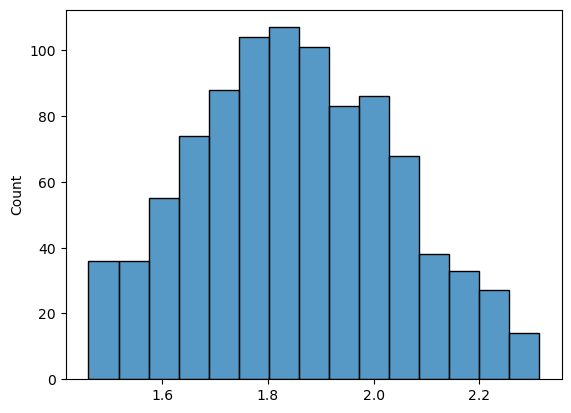

In [96]:
sb.histplot(maes)

In [97]:
model.coef_

array([-2.27728226e+00, -3.07817714e-01,  1.80681170e+01, -9.05789975e-01,
        2.38775811e-01, -1.01828826e+00,  2.75357352e+00,  1.55695258e-01,
       -1.10160955e+00, -9.19322776e-01,  1.76250567e-02])

In [98]:
X_train_encoded

,age,traveltime,G1,studytime,Medu,failures,absences,Mjob_encoded,Fjob_encoded,schoolsup_encoded,higher_encoded
265,18,2,17,2,3,0,13,9.856016,10.138298,10.61,10.637195
170,16,3,6,1,3,2,0,9.856016,10.138298,10.61,10.637195
93,16,2,11,2,4,0,0,11.042868,10.373765,10.61,10.637195
298,18,1,14,4,4,0,0,9.856016,10.138298,10.61,10.637195
3,15,1,15,3,4,0,2,11.665062,10.373765,10.61,10.637195
...,...,...,...,...,...,...,...,...,...,...,...
133,16,1,12,1,3,0,16,11.064758,10.138298,10.61,10.637195
186,16,1,11,1,1,0,2,11.064758,10.373765,10.61,10.637195
37,16,2,15,3,4,0,7,9.856016,11.577238,10.61,10.637195
302,17,2,15,3,4,0,0,9.856016,10.138298,10.61,10.637195


In [99]:
for x, y in zip(X_train_encoded.columns, model.coef_):
    print(x, round(y, 2))

age -2.28
traveltime -0.31
G1 18.07
studytime -0.91
Medu 0.24
failures -1.02
absences 2.75
Mjob_encoded 0.16
Fjob_encoded -1.1
schoolsup_encoded -0.92
higher_encoded 0.02


In [100]:
X_y_train.groupby('age').agg({'y':'mean'})

,y
age,
15,11.276316
16,10.912088
17,10.880952
18,9.132353
19,8.086957
20,13.500000
21,7.000000


c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='age', ylabel='y'>

c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\LEDI\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


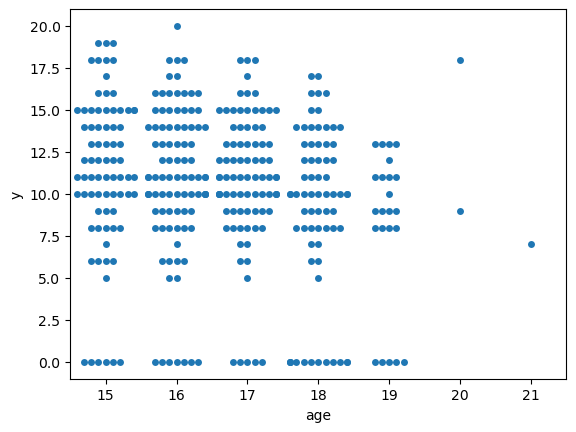

In [103]:
sb.swarmplot(x=X_y_train['age'],y=X_y_train['y'])